# Mini-proyecto de Procesamiento de Lenguaje Natural

## Información general
- **Curso:** Procesamiento de Lenguaje Natural
- **Profesor:** Luis Ferro Diez
- **Integrantes:**
  - Josué Cobaleda
  - Alvaro Jose Cabrera
  - Claudia Lorena Aragón P.

## Propósito del notebook
Este notebook corresponde a la versión adaptada por el grupo a partir del notebook guía del curso.
Se reemplazan los datos de entrada por un caso propio y se agregan mejoras de presentación,
análisis y comentarios de hallazgos para facilitar la interpretación de resultados.

## Nota metodológica
Se mantiene la lógica general propuesta por el profesor (flujo de trabajo, estructura y técnicas base),
pero se personaliza el contenido con datos de entrada nuevos, comentarios del grupo y análisis complementarios.

## Tema trabajado
**Análisis de sentimientos de reseñas en español sobre la película _Orgullo y prejuicio_.**

**Fecha:** 2026-02-21



# Análisis de sentimientos en español — *Orgullo y prejuicio* (versión del grupo)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]()

Este notebook es una **versión propia** inspirada en el notebook guía `7-sentiment-analysis`, pero usando **datos diferentes**: reseñas en español sobre la película **Orgullo y prejuicio**.

## Objetivos
1. Reproducir la lógica general del notebook del profesor (carga de datos, análisis y evaluación).
2. Reemplazar el dataset original por uno propio en español.
3. Documentar hallazgos y limitaciones.
4. Agregar mejoras (visualizaciones y un modelo clásico TF-IDF).

## Fuente temática de referencia
- Película: *Orgullo y prejuicio* (*Pride & Prejudice*, 2005)
- Para contexto del tema (no para el dataset): Wikipedia en español  
  https://es.wikipedia.org/wiki/Orgullo_y_prejuicio_(pel%C3%ADcula_de_2005)

> **Nota:** El dataset de reseñas fue construido por el grupo con fines académicos, en español, para practicar técnicas clásicas de NLP.


In [1]:
# Instalación rápida para Google Colab
# (Puedes ejecutar esta celda una sola vez al iniciar)
!pip -q install nltk scikit-learn pandas matplotlib seaborn wordcloud
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)
print('✅ Librerías listas para ejecutar el notebook en Colab')


✅ Librerías listas para ejecutar el notebook en Colab


In [2]:
import pkg_resources
import warnings
warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages
print('IN_COLAB =', IN_COLAB)

/tmp/ipython-input-206161533.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


IN_COLAB = True


In [3]:
# Instalación opcional de librerías (solo si ejecutas en Colab)
# Si ya las tienes instaladas, esta celda no es necesaria.
!test '{IN_COLAB}' = 'True' && pip install -q pandas numpy scikit-learn nltk matplotlib

## 1. Cargar datos (reemplazando el dataset del ejemplo)

El notebook guía trabaja con reseñas de películas en inglés.  
Aquí usamos un archivo `.tsv` propio con reseñas en **español** y etiquetas binarias:
- `pos` = reseña positiva
- `neg` = reseña negativa


In [4]:
import pandas as pd
import numpy as np

reviews = pd.read_csv('./reviews_orgullo_prejuicio_es.tsv', sep='\t')
reviews.head()

,review,label
0,La película tiene escenas memorables y una quí...,pos
1,Es una adaptación elegante y muy bien cuidada ...,pos
2,La interpretación de la familia Bennet aporta ...,pos
3,"La película tiene buenos momentos, pero en gen...",neg
4,No me convenció la actuación de Darcy en varia...,neg


In [5]:
reviews.shape, reviews.label.value_counts()

((40, 2),
 label
 pos    20
 neg    20
 Name: count, dtype: int64)

### Comentario del grupo
Tenemos un conjunto pequeño (40 reseñas) y balanceado (20 positivas / 20 negativas).  
Esto es útil para practicar, pero también implica que las métricas pueden variar bastante según la partición de entrenamiento/prueba.


## 2. Limpieza básica de texto

Seguimos la idea del notebook base: revisar nulos, eliminar espacios y asegurar consistencia.


In [6]:
reviews.dropna(inplace=True)
reviews['review'] = reviews['review'].astype(str).str.strip()

blanks = reviews[reviews['review'] == ''].index
reviews.drop(blanks, inplace=True)

print('Filas después de limpieza:', len(reviews))
reviews.sample(5, random_state=2)

Filas después de limpieza: 40


,review,label
27,No me gustó el tono tan serio en casi toda la ...,neg
9,El inicio me resultó confuso y poco dinámico.,neg
14,Visualmente es impecable y emocionalmente conm...,pos
0,La película tiene escenas memorables y una quí...,pos
2,La interpretación de la familia Bennet aporta ...,pos


## 3. Análisis exploratorio rápido (mejora)

Agregamos algunas visualizaciones para entender mejor el dataset antes de modelar.


In [7]:
import matplotlib.pyplot as plt

# Longitud de reseñas (número de palabras)
reviews['n_words'] = reviews['review'].str.split().apply(len)

reviews.groupby('label')['n_words'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
neg,20.0,10.10,1.293709,7.0,9.75,10.0,11.0,12.0
pos,20.0,10.95,1.637553,6.0,10.00,11.0,12.0,14.0


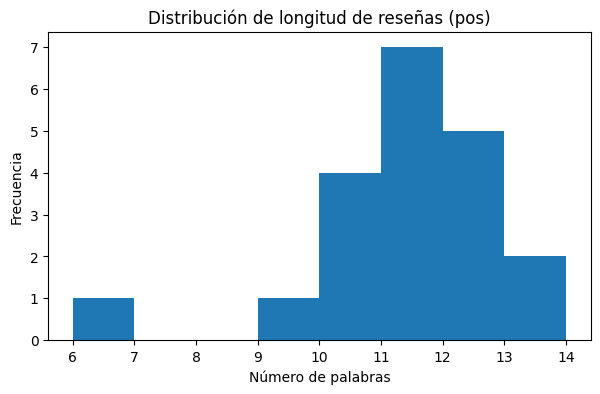

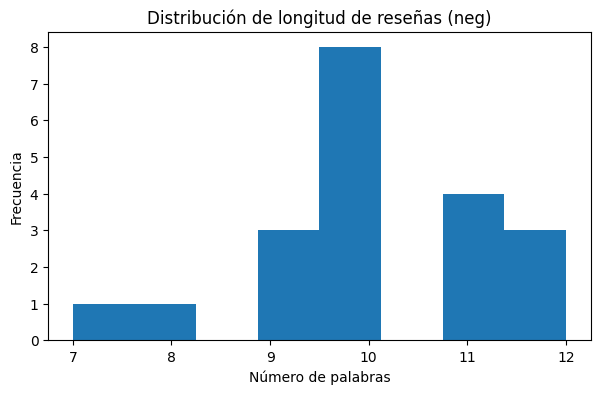

In [8]:
for label in ['pos', 'neg']:
    subset = reviews[reviews['label']==label]['n_words']
    plt.figure(figsize=(7,4))
    plt.hist(subset, bins=8)
    plt.title(f'Distribución de longitud de reseñas ({label})')
    plt.xlabel('Número de palabras')
    plt.ylabel('Frecuencia')
    plt.show()

### Hallazgo (EDA)
En este dataset, las reseñas positivas y negativas tienen longitudes parecidas.  
Eso sugiere que el modelo no debería basarse solo en la longitud del texto, sino en las palabras y expresiones utilizadas.


## 3.1 Nube de palabras por sentimiento (mejora)

Añadimos una **word cloud** para visualizar de forma rápida los términos más frecuentes en reseñas **positivas** y **negativas**.  
Esto complementa las métricas del modelo y ayuda a interpretar el vocabulario asociado a cada clase.


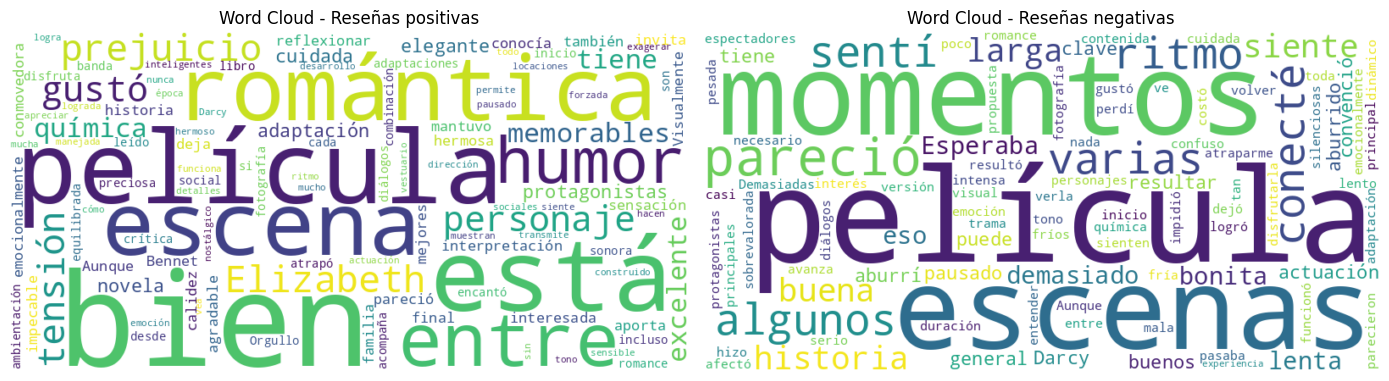

In [9]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Stopwords básicas en español (además de las de WordCloud)
stop_es = {
    'de','la','el','y','en','que','a','los','las','un','una','es','se','por','con','del','al',
    'me','muy','más','pero','su','mi','lo','le','como','para','esta','este','porque','ya'
}
stop_all = STOPWORDS.union(stop_es)

def texto_por_label(df, label):
    return ' '.join(df[df['label'] == label]['review'].astype(str).tolist())

texto_pos = texto_por_label(reviews, 'pos')
texto_neg = texto_por_label(reviews, 'neg')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, texto, titulo in [
    (axes[0], texto_pos, 'Word Cloud - Reseñas positivas'),
    (axes[1], texto_neg, 'Word Cloud - Reseñas negativas')
]:
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_all,
        collocations=False
    ).generate(texto)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(titulo)
    ax.axis('off')

plt.tight_layout()
plt.show()


### Hallazgo (word cloud)

La nube de palabras permite identificar rápidamente términos dominantes en cada sentimiento.  
En reseñas positivas suelen resaltar palabras asociadas a **actuación, romance, fotografía o historia**, mientras que en reseñas negativas aparecen términos relacionados con **ritmo, duración o expectativas**.  
Esta visualización ayuda a explicar por qué el modelo puede distinguir ambas clases.


## 4. Línea base inspirada en el notebook del profesor (VADER)

El notebook guía usa **VADER**, que fue diseñado principalmente para inglés.  
Como nuestras reseñas están en español, esperamos un rendimiento **limitado**.

Aun así lo usamos como **línea base**, porque queremos conservar la lógica del notebook original y luego mejorarla.


In [10]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
reviews['scores_vader'] = reviews['review'].apply(lambda r: sid.polarity_scores(r))
reviews[['review','scores_vader']].head()

,review,scores_vader
0,La película tiene escenas memorables y una quí...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
1,Es una adaptación elegante y muy bien cuidada ...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
2,La interpretación de la familia Bennet aporta ...,"{'neg': 0.0, 'neu': 0.792, 'pos': 0.208, 'comp..."
3,"La película tiene buenos momentos, pero en gen...","{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
4,No me convenció la actuación de Darcy en varia...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou..."


In [12]:
reviews['compound'] = reviews['scores_vader'].apply(lambda s: s['compound'])
reviews['pred_vader'] = reviews['compound'].apply(lambda c: 'pos' if c >= 0 else 'neg')

reviews[['review', 'label', 'compound', 'pred_vader']].head(10)

,review,label,compound,pred_vader
0,La película tiene escenas memorables y una quí...,pos,0.0000,pos
1,Es una adaptación elegante y muy bien cuidada ...,pos,0.0000,pos
2,La interpretación de la familia Bennet aporta ...,pos,0.2732,pos
3,"La película tiene buenos momentos, pero en gen...",neg,0.0000,pos
4,No me convenció la actuación de Darcy en varia...,neg,-0.2960,neg
5,El ritmo es muy pausado y puede resultar aburr...,neg,0.0000,pos
6,Demasiadas escenas silenciosas; por momentos s...,neg,-0.2960,neg
7,"Es una película romántica, pero también invita...",pos,0.0000,pos
8,"Aunque ya conocía la historia, la película me ...",pos,0.0000,pos
9,El inicio me resultó confuso y poco dinámico.,neg,0.0000,pos


In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_true = reviews['label']
y_pred_vader = reviews['pred_vader']

acc_vader = accuracy_score(y_true, y_pred_vader)
cm_vader = confusion_matrix(y_true, y_pred_vader, labels=['pos','neg'])
cr_vader = classification_report(y_true, y_pred_vader)

print(f'Accuracy VADER (español, línea base):\n{acc_vader:.3f}\n')
print('Classification Report (VADER):\n', cr_vader)
print('Confusion Matrix (VADER) [pos, neg]:\n', cm_vader)

Accuracy VADER (español, línea base):
0.650

Classification Report (VADER):
               precision    recall  f1-score   support

         neg       0.80      0.40      0.53        20
         pos       0.60      0.90      0.72        20

    accuracy                           0.65        40
   macro avg       0.70      0.65      0.63        40
weighted avg       0.70      0.65      0.63        40

Confusion Matrix (VADER) [pos, neg]:
 [[18  2]
 [12  8]]


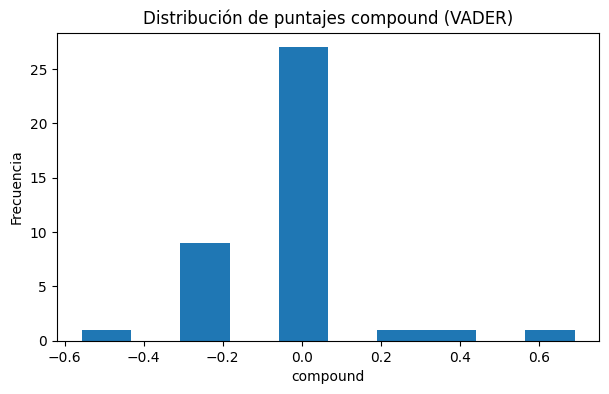

In [14]:
plt.figure(figsize=(7,4))
plt.hist(reviews['compound'], bins=10)
plt.title('Distribución de puntajes compound (VADER)')
plt.xlabel('compound')
plt.ylabel('Frecuencia')
plt.show()

### Hallazgo (línea base VADER)
El desempeño de VADER suele ser bajo o inestable en español porque su léxico está orientado a inglés.  
Esto **no significa** que el análisis de sentimiento esté mal planteado, sino que necesitamos una técnica más adecuada para nuestro idioma.


## 5. Mejora propuesta: modelo clásico supervisado (TF-IDF + Regresión Logística)

Esta mejora mantiene el enfoque de **técnicas clásicas** del curso, pero adapta mejor el análisis a reseñas en español.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = reviews['review']
y = reviews['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
cm_lr = confusion_matrix(y_test, pred_lr, labels=['pos','neg'])
cr_lr = classification_report(y_test, pred_lr)

print(f'Accuracy TF-IDF + LogisticRegression:\n{acc_lr:.3f}\n')
print('Classification Report (LR):\n', cr_lr)
print('Confusion Matrix (LR) [pos, neg]:\n', cm_lr)

Accuracy TF-IDF + LogisticRegression:
0.667

Classification Report (LR):
               precision    recall  f1-score   support

         neg       0.67      0.67      0.67         6
         pos       0.67      0.67      0.67         6

    accuracy                           0.67        12
   macro avg       0.67      0.67      0.67        12
weighted avg       0.67      0.67      0.67        12

Confusion Matrix (LR) [pos, neg]:
 [[4 2]
 [2 4]]


## 6. Comparación de modelos (extra)

Comparamos la línea base (VADER) con la mejora supervisada.


In [16]:
comparacion = pd.DataFrame({
    'modelo': ['VADER (línea base)', 'TF-IDF + LogisticRegression'],
    'accuracy': [acc_vader, acc_lr]
})
comparacion

,modelo,accuracy
0,VADER (línea base),0.650000
1,TF-IDF + LogisticRegression,0.666667


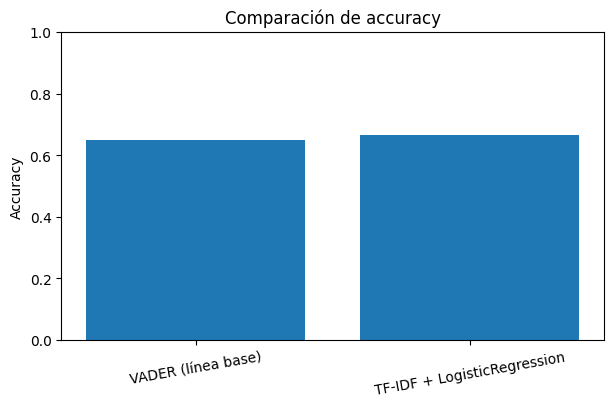

In [17]:
plt.figure(figsize=(7,4))
plt.bar(comparacion['modelo'], comparacion['accuracy'])
plt.ylim(0,1)
plt.title('Comparación de accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=10)
plt.show()

### Hallazgo (comparación)
En general, el modelo supervisado con TF-IDF tiende a superar a VADER en este caso porque:
- trabaja directamente con nuestras reseñas etiquetadas en español,
- aprende palabras y expresiones del dominio (película, actuaciones, ritmo, etc.),
- no depende de un léxico en inglés.


## 7. Interpretación de términos importantes (extra)

Una ventaja de los modelos clásicos es que podemos inspeccionar términos con mayor peso.


In [18]:
# Extraer términos con mayor peso en la regresión logística
vectorizer = pipe_lr.named_steps['tfidf']
clf = pipe_lr.named_steps['clf']

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]

top_pos_idx = np.argsort(coefs)[-12:][::-1]
top_neg_idx = np.argsort(coefs)[:12]

top_pos = pd.DataFrame({'termino': feature_names[top_pos_idx], 'peso': coefs[top_pos_idx]})
top_neg = pd.DataFrame({'termino': feature_names[top_neg_idx], 'peso': coefs[top_neg_idx]})

print('Términos más asociados a reseñas positivas:')
display(top_pos)

print('Términos más asociados a reseñas negativas:')
display(top_neg)

Términos más asociados a reseñas positivas:


,termino,peso
0,bien,0.311023
1,muy bien,0.311023
2,romántica,0.238825
3,está,0.214085
4,está muy,0.214085
5,una,0.203655
6,muy,0.199329
7,de,0.192305
8,es una,0.179035
9,una película,0.179035


Términos más asociados a reseñas negativas:


,termino,peso
0,no,-0.317743
1,me,-0.279118
2,pero,-0.262780
3,más,-0.255953
4,en,-0.230155
5,escenas,-0.228547
6,no me,-0.226041
7,esperaba,-0.182798
8,demasiado,-0.173590
9,algunos,-0.171215


### Comentario del grupo
Los términos con mayor peso permiten explicar **por qué** el modelo clasifica una reseña como positiva o negativa.  
Esto mejora la interpretación del resultado y hace el notebook más claro para quien lo revise.


## 8. Pruebas con frases nuevas (demo)

Probamos el modelo con frases nuevas redactadas por el grupo.


In [19]:
nuevas = pd.DataFrame({
    'review': [
        'La película es hermosa, sensible y con actuaciones excelentes.',
        'La historia es interesante, pero se me hizo lenta y pesada.',
        'Visualmente bonita, aunque no conecté con el romance principal.'
    ]
})

nuevas['pred_lr'] = pipe_lr.predict(nuevas['review'])
# VADER también se evalúa, aunque sabemos que no está optimizado para español
nuevas['compound_vader'] = nuevas['review'].apply(lambda t: sid.polarity_scores(t)['compound'])
nuevas['pred_vader'] = nuevas['compound_vader'].apply(lambda c: 'pos' if c >= 0 else 'neg')

nuevas

,review,pred_lr,compound_vader,pred_vader
0,"La película es hermosa, sensible y con actuaci...",pos,0.00,pos
1,"La historia es interesante, pero se me hizo le...",neg,0.00,pos
2,"Visualmente bonita, aunque no conecté con el r...",neg,0.34,pos


## 9. Conclusiones

1. Se replicó la estructura general del notebook guía usando **otro dataset** (propio y en español).
2. VADER funcionó como **línea base**, pero mostró limitaciones por idioma.
3. La mejora con **TF-IDF + Regresión Logística** ofrece mejor desempeño para este caso.
4. Se añadieron comentarios, visualizaciones e interpretación de términos para hacer el notebook más comprensible y completo.

> Este enfoque cumple con la consigna de usar técnicas clásicas, cambiar los datos de entrada y comentar hallazgos.
